# 01 — EDA : Dataset The Beauty API

L'objectif de ce notebook est d'explorer la distribution des catégories et des attributs de formulation via la liste INCI avec (`contains_*`), et avoir une première intuition visuelle du lien packaging avec la composition INCI avant de passer au computer vision avancé

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os

sns.set_theme(style="whitegrid")

df = pd.read_parquet("../data/processed/dataset_clean.parquet")
target_cols = [
    "contains_fragrance",
    "contains_drying_alcohol",
    "contains_parabens",
    "contains_sulfates",
    "contains_silicones",
]
df.shape

(1000, 11)

## 1. Distribution des catégories

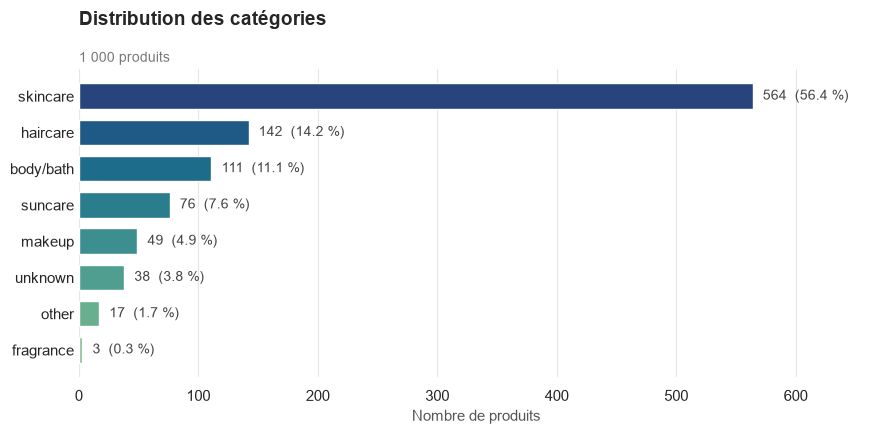

In [4]:
counts = df["category"].value_counts()
shares = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(
    counts.index,
    counts.values,
    color=sns.color_palette("crest", len(counts))[::-1],
    height=0.7,
)
ax.invert_yaxis()

for bar, n, pct in zip(bars, counts.values, shares.values):
    ax.text(
        bar.get_width() + counts.max() * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{n}  ({pct:.1f} %)",
        va="center",
        fontsize=10,
        color="#444444",
    )

ax.set_title("Distribution des catégories", fontsize=14, fontweight="bold", pad=32, loc="left")
ax.text(
    0, 1.015, f"{len(df):,} produits".replace(",", " "),
    transform=ax.transAxes, fontsize=10, color="#777777", va="bottom",
)
ax.set_xlabel("Nombre de produits", fontsize=11, color="#555555")
ax.set_ylabel("")
ax.set_xlim(0, counts.max() * 1.18)
ax.tick_params(axis="y", length=0, labelsize=11)
ax.xaxis.grid(True, color="#e6e6e6", linewidth=0.8)
ax.yaxis.grid(False)
ax.set_axisbelow(True)
sns.despine(ax=ax, left=True, bottom=True)

plt.tight_layout()
plt.show()

Les catégories rares (`fragrance`, `other`, `unknown`) seront probablement à regrouper en "autre" avant la modélisation, ou exclues si trop peu représentées pour un split train/test propre.

## 2. Distribution des attributs de formulation (targets)

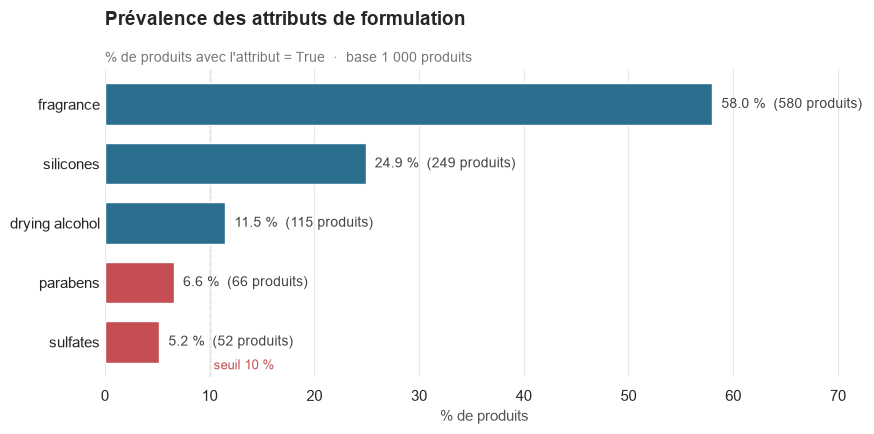

contains_fragrance         58.0
contains_silicones         24.9
contains_drying_alcohol    11.5
contains_parabens           6.6
contains_sulfates           5.2
dtype: float64

In [6]:
proportions = df[target_cols].mean().sort_values(ascending=False) * 100
n_true = df[proportions.index].sum()
labels = [c.replace("contains_", "").replace("_", " ") for c in proportions.index]

RARE_THRESHOLD = 10 

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(
    labels,
    proportions.values,
    color=["#c44e52" if p < RARE_THRESHOLD else "#2a6f8e" for p in proportions.values],
    height=0.7,
)
ax.invert_yaxis()

for bar, pct, n in zip(bars, proportions.values, n_true.values):
    ax.text(
        bar.get_width() + proportions.max() * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{pct:.1f} %  ({n} produits)",
        va="center",
        fontsize=10,
        color="#444444",
    )

ax.axvline(RARE_THRESHOLD, color="#c44e52", linestyle="--", linewidth=1, alpha=0.5, zorder=0)
ax.text(
    RARE_THRESHOLD, 0.015, f" seuil {RARE_THRESHOLD} %",
    transform=ax.get_xaxis_transform(), fontsize=9, color="#c44e52", va="bottom",
)

ax.set_title(
    "Prévalence des attributs de formulation",
    fontsize=14, fontweight="bold", pad=32, loc="left",
)
ax.text(
    0, 1.015, f"% de produits avec l'attribut = True  ·  base {len(df):,} produits".replace(",", " "),
    transform=ax.transAxes, fontsize=10, color="#777777", va="bottom",
)
ax.set_xlabel("% de produits", fontsize=11, color="#555555")
ax.set_ylabel("")
ax.set_xlim(0, proportions.max() * 1.25)
ax.tick_params(axis="y", length=0, labelsize=11)
ax.xaxis.grid(True, color="#e6e6e6", linewidth=0.8)
ax.yaxis.grid(False)
ax.set_axisbelow(True)
sns.despine(ax=ax, left=True, bottom=True)

plt.tight_layout()
plt.show()

proportions

Fort déséquilibre pour `contains_parabens` et `contains_sulfates` (- de 7% de True )
A garder en tête pour le choix de métrique en modélisation, peut-être AUC-ROC / F1 plutôt qu'accuracy

## 3. Croisement catégorie × attributs

Cette partie sert à vérifier si un attribut est surtout expliqué par la catégorie de produit (ex: silicones plus fréquents en haircare), c'estimportant pour ne pas confondre un signal "catégorie" avec un vrai signal "packaging visuel" plus tard

In [7]:
cross = df.groupby("category")[target_cols].mean().round(2) * 100
cross

,contains_fragrance,contains_drying_alcohol,contains_parabens,contains_sulfates,contains_silicones
category,,,,,
body/bath,68.0,7.0,7.0,8.0,14.0
fragrance,100.0,100.0,0.0,0.0,0.0
haircare,86.0,17.0,6.0,18.0,23.0
makeup,35.0,12.0,4.0,0.0,49.0
other,35.0,18.0,18.0,24.0,29.0
skincare,54.0,10.0,7.0,2.0,20.0
suncare,41.0,12.0,3.0,0.0,64.0
unknown,50.0,8.0,3.0,3.0,24.0


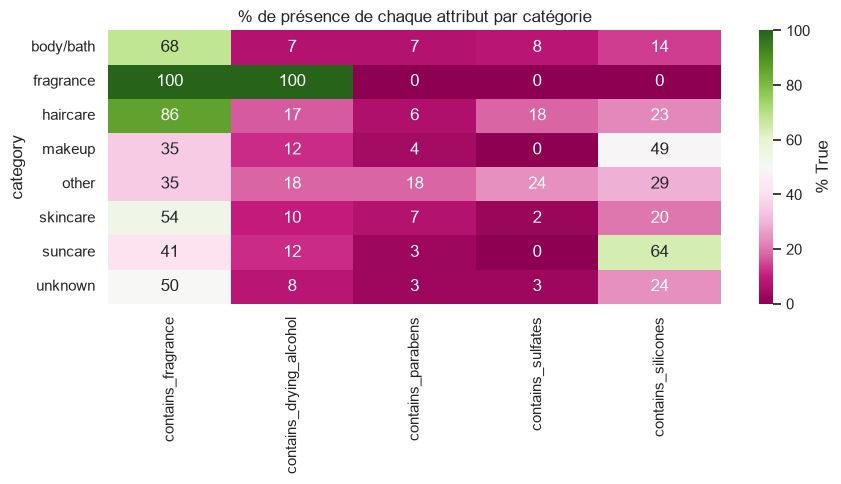

In [9]:
plt.figure(figsize=(9, 5))
sns.heatmap(cross, annot=True, fmt=".0f", cmap="PiYG", cbar_kws={"label": "% True"})
plt.title("% de présence de chaque attribut par catégorie")
plt.tight_layout()
plt.show()

## 4. Aperçu visuel : quelques exemples par catégorie

Contrôle qualité simple — vérifier que les images sont bien exploitables (pas floues, pas coupées, avec le packaging vraiment visible)

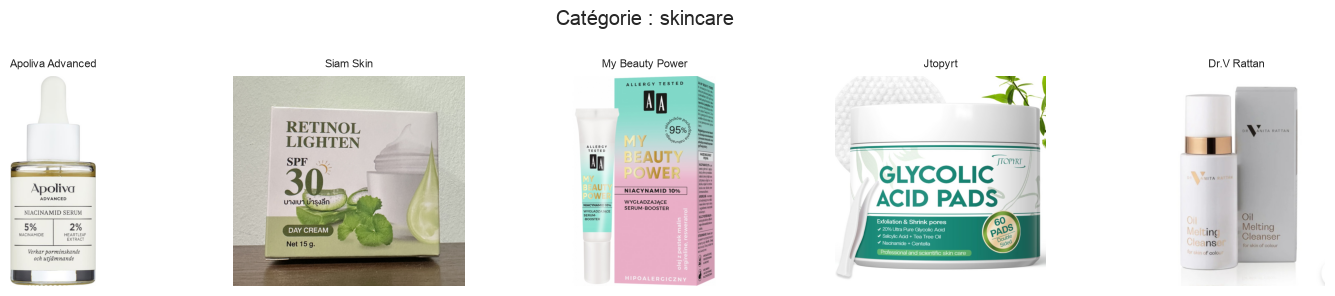

In [10]:
def show_examples(category, n=5):
    subset = df[df["category"] == category].sample(min(n, len(df[df["category"] == category])), random_state=42)
    fig, axes = plt.subplots(1, len(subset), figsize=(3 * len(subset), 3))
    if len(subset) == 1:
        axes = [axes]
    for ax, (_, row) in zip(axes, subset.iterrows()):
        img_path = os.path.join("..", row["image_path"])
        img = Image.open(img_path)
        ax.imshow(img)
        ax.set_title(row["brand"][:20], fontsize=8)
        ax.axis("off")
    plt.suptitle(f"Catégorie : {category}")
    plt.tight_layout()
    plt.show()

show_examples("skincare")

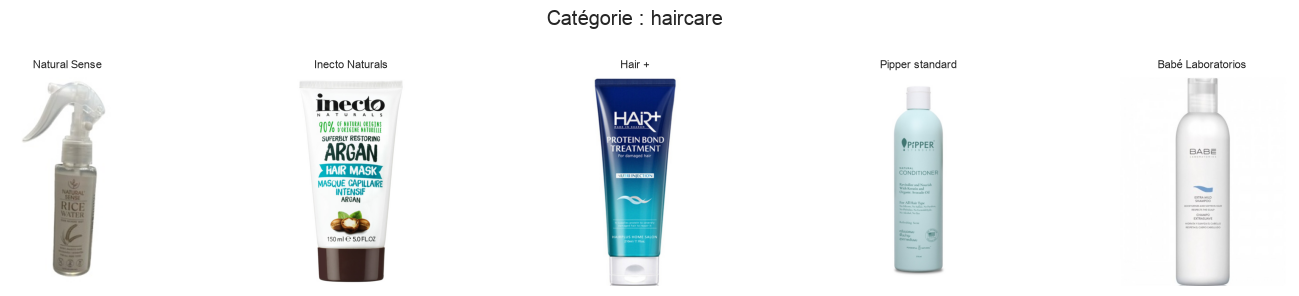

In [11]:
show_examples("haircare")

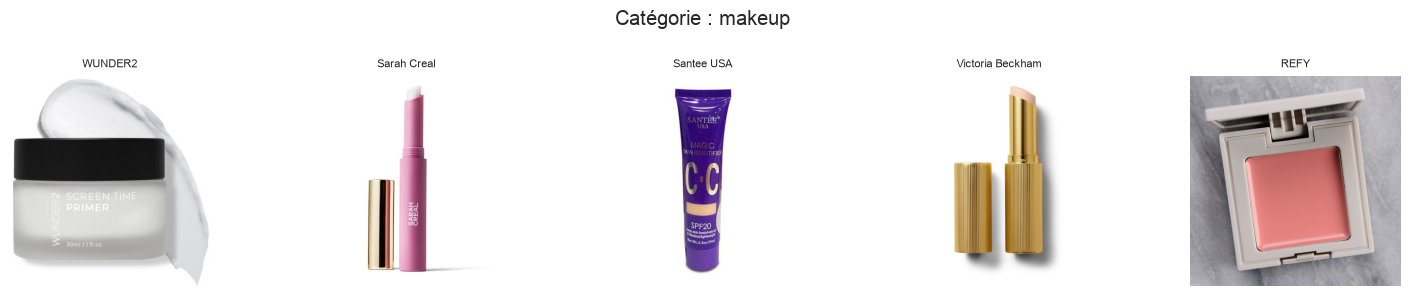

In [12]:
show_examples("makeup")

## 5. Intuition visuelle : fragrance vs sans fragrance

Comparaison côte à côte — est-ce qu'on devine à l'œil un signal (couleurs, style d'étiquette, minimalisme) avant même de faire du CV ?

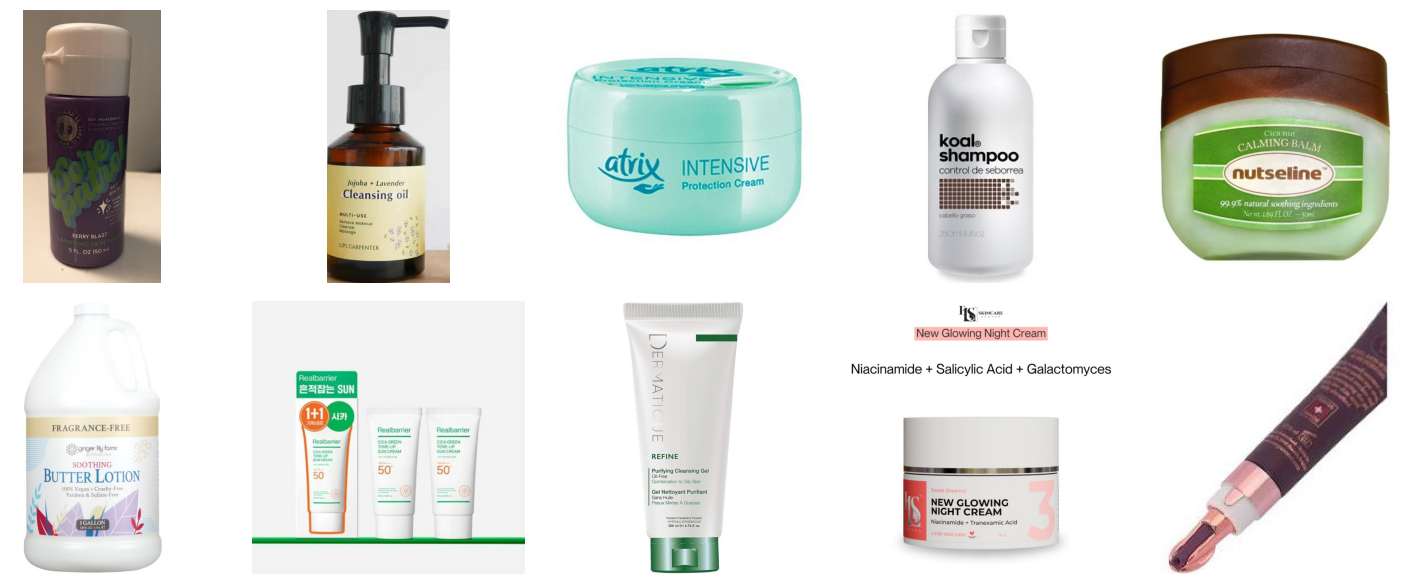

In [13]:
def compare_attribute(attribute, n=5):
    with_attr = df[df[attribute] == True].sample(min(n, (df[attribute] == True).sum()), random_state=42)
    without_attr = df[df[attribute] == False].sample(min(n, (df[attribute] == False).sum()), random_state=42)

    fig, axes = plt.subplots(2, n, figsize=(3 * n, 6))
    for ax, (_, row) in zip(axes[0], with_attr.iterrows()):
        img = Image.open(os.path.join("..", row["image_path"]))
        ax.imshow(img)
        ax.axis("off")
    axes[0, 0].set_ylabel(f"{attribute} = True", fontsize=10)

    for ax, (_, row) in zip(axes[1], without_attr.iterrows()):
        img = Image.open(os.path.join("..", row["image_path"]))
        ax.imshow(img)
        ax.axis("off")
    axes[1, 0].set_ylabel(f"{attribute} = False", fontsize=10)

    plt.tight_layout()
    plt.show()

compare_attribute("contains_fragrance")

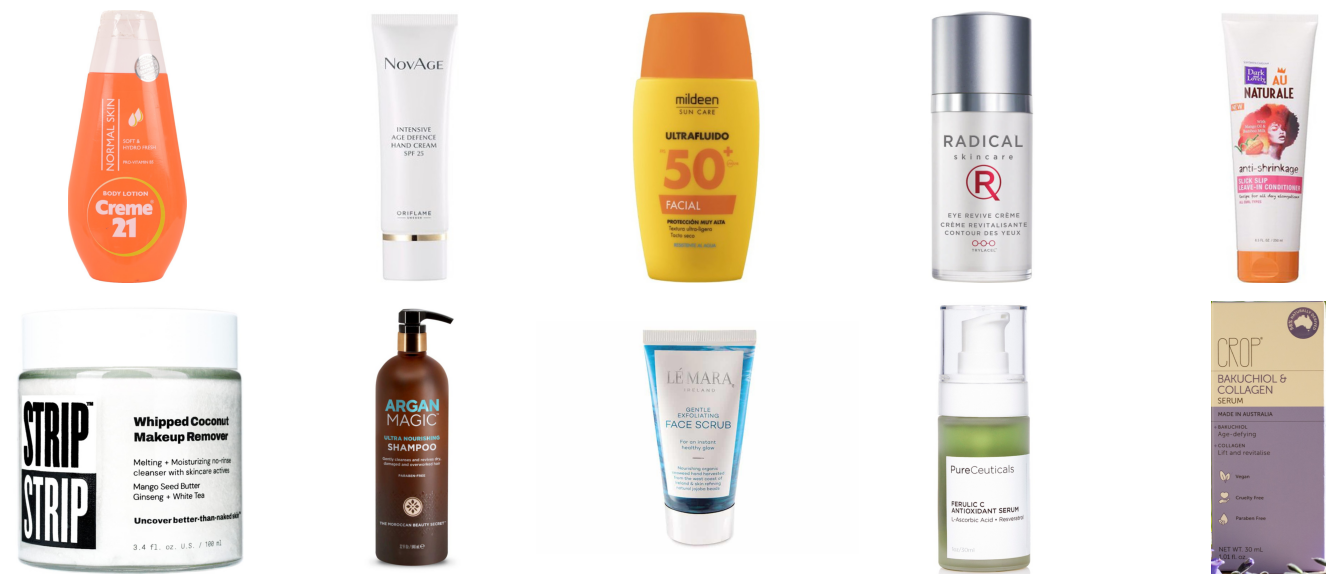

In [14]:
compare_attribute("contains_silicones")